# Phase 4: Deployment & XAI Integration
## Evaluating Large Language Models for Generative Question Answering

### Overview
This notebook addresses the real-world transition of our LLM-based QA evaluation pipeline.
We cover:
1. **Model Deployment** — how the pipeline would operate in production
2. **Explainable AI (XAI)** — why the pipeline makes the decisions it does

> **Note:** This project is an NLP evaluation research pipeline, not a traditional ML model.
> Rubric requirements are adapted accordingly:
> - **Feature Importance** → SHAP analysis on a Gradient Boosting surrogate model trained
>   to predict LLM Judge scores from interpretable features (BERTScore, ROUGE, F1, answer length, etc.)
> - **Global/Local Explanations** → overall pipeline logic + per-answer SHAP waterfall breakdown
> - **Bias & Fairness** → performance audit across model identity, answer length, and question length
> - **Deployment** → production architecture mockup + monitoring strategy

## Roles and Responsibilities

| Member | Responsibility |
|---|---|
| **Aryan Patial** | Deployment architecture, API mockup, production workflow design |
| **Vaishnavi Maramreddy** | Monitoring & maintenance strategy, data drift analysis |
| **Sathvik Addicharla** | Global & Local XAI explanations, SHAP analysis |
| **Sumanth Mallesh Guthi** | Bias & Fairness audit, ethical implications, visualizations |

---
# Step 0: Install Dependencies

In [1]:
!pip install shap -q
!pip install pandas numpy matplotlib seaborn scipy scikit-learn -q
!pip install openai -q
print('✅ All dependencies installed')

✅ All dependencies installed


---
# Step 1: Load Data from Phase 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 150

# ── Load Phase 3 outputs ───────────────────────────────────
all_answers_df = pd.read_csv('/content/drive/MyDrive/phase3/all_answers_final.csv')
human_eval_df  = pd.read_csv('/content/drive/MyDrive/phase3/human_eval_scored.csv')

# ── Rebuild merged_df ─────────────────────────────────────
metrics_df = all_answers_df[['question', 'model_name', 'exact_match',
                              'f1_score', 'bleu_score', 'rouge_l',
                              'bertscore_f1', 'llm_judge_score']]
merged_df = human_eval_df.merge(metrics_df, on=['question', 'model_name'], how='inner')

# ── Feature engineering for XAI ──────────────────────────
all_answers_df['question_length'] = all_answers_df['question'].apply(
    lambda x: len(str(x).split()))
all_answers_df['answer_length'] = all_answers_df['generated_answer'].apply(
    lambda x: len(str(x).split()))
all_answers_df['model_encoded'] = LabelEncoder().fit_transform(
    all_answers_df['model_name'])

# Check if article_text column is available
has_article_length = 'article_text' in all_answers_df.columns
if has_article_length:
    all_answers_df['article_length'] = all_answers_df['article_text'].apply(
        lambda x: len(str(x).split()))
    print('✅ article_text found — article_length computed')
else:
    print('⚠️  article_text not found — article_length will not be used in audit')

print(f'\n✅ Data loaded!')
print(f'   all_answers_df : {len(all_answers_df)} rows')
print(f'   merged_df      : {len(merged_df)} rows')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ article_text found — article_length computed

✅ Data loaded!
   all_answers_df : 800 rows
   merged_df      : 100 rows


---
# PART 1: MODEL DEPLOYMENT

## Step 2: Production Architecture

Our QA evaluation pipeline would operate in production as follows:

```
┌─────────────────────────────────────────────────────────────────┐
│                    PRODUCTION ARCHITECTURE                       │
│                                                                  │
│  [User / Client App]                                            │
│        │                                                        │
│        ▼  POST /evaluate                                        │
│  [FastAPI REST Endpoint]  ←── document_text + question         │
│        │           ▲── API Key Header (Bearer Token)           │
│        │                                                        │
│        ├──▶ [Auth Layer]  (API key validation)                 │
│        │                                                        │
│        ├──▶ [LLM Inference Layer]  (Llama / Qwen via HF)      │
│        │         └──▶ generated_answer                         │
│        │                                                        │
│        ├──▶ [Metrics Engine]                                   │
│        │         ├── BLEU / ROUGE / BERTScore                  │
│        │         └── LLM Judge (GPT-4o-mini)                  │
│        │                                                        │
│        ├──▶ [Score Aggregator]                                 │
│        │                                                        │
│        └──▶ [Response]  ←── answer + scores + quality_label   │
│                                                                  │
│  Infrastructure: Docker → AWS Lambda / GCP Cloud Run            │
│  Rate Limiting:  100 req/min per API key (via Redis)            │
│  Mode: BATCH (200 articles/run) or REAL-TIME (single query)    │
└─────────────────────────────────────────────────────────────────┘
```

### Batch vs Real-Time
- **Batch mode** (current): Process 200 articles overnight, save results to CSV/database
- **Real-time mode** (production): Single document + question via API, response in ~2-5 seconds
- For enterprise QA auditing, **batch is preferred** due to GPU cost optimization

## Step 3: API / Interface Mockup

Below is a production-ready function simulating what the deployed REST API endpoint would do.
In production this would be wrapped in **FastAPI**, containerized with **Docker**,
and deployed on **AWS Lambda** or **GCP Cloud Run**.

> **Note on Answer Generation:** In this Phase 4 mockup, answer generation uses the same
> open-source Hugging Face models as our research pipeline — **Llama-3.1-8B-Instruct**
> and **Qwen2-7B-Instruct** — loaded on Colab GPU. To make inference more practical in Colab,
> the models are loaded with 4-bit quantization. The LLM judge remains **GPT-4o-mini**,
> consistent with our earlier evaluation pipeline.

In [ ]:
# ── Production API Mockup ─────────────────────────────────
# Simulates: POST /evaluate
# In production: FastAPI + Docker + AWS/GCP
# Auth: Bearer token in request headers
# Rate limit: 100 requests/min per key via Redis

!pip install -q -U transformers accelerate bitsandbytes sentencepiece

import time, torch, re
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from openai import OpenAI
from google.colab import userdata

# Judge client (optional: keep GPT judge)
judge_client = OpenAI(api_key=userdata.get('GPT-4o'))

HF_MODELS = {
    "llama": "meta-llama/Meta-Llama-3.1-8B-Instruct",
    "qwen": "Qwen/Qwen2-7B-Instruct"
}

loaded_models = {}

def load_hf_model(model_key="qwen"):
    if model_key in loaded_models:
        return loaded_models[model_key]

    model_id = HF_MODELS[model_key]

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=quant_config,
        device_map="auto",
        torch_dtype=torch.float16
    )
    model.eval()

    loaded_models[model_key] = (tokenizer, model)
    return tokenizer, model

def hf_generate(document_text: str, question: str, model_key="qwen", max_new_tokens=150):
    tokenizer, model = load_hf_model(model_key)

    messages = [
        {
            "role": "system",
            "content": "Answer the question using ONLY information from the article. Be concise."
        },
        {
            "role": "user",
            "content": f"Article: {document_text[:2000]}\n\nQuestion: {question}\n\nAnswer:"
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    generated_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    return generated_answer

def evaluate_document(document_text: str,
                      question: str,
                      reference_answer: str = "",
                      model_key: str = "qwen",
                      judge_mode: str = "gpt") -> dict:
    """
    PRODUCTION API ENDPOINT MOCKUP
    --------------------------------
    Simulates: POST /evaluate

    Request body:
    {
        "document": "...",
        "question": "...",
        "reference_answer": "...",   # optional
        "model_key": "qwen"          # or "llama"
    }

    Returns:
    answer + scores + quality label + processing time
    """

    start_time = time.time()

    # ── Step 1: Generate Answer ───────────────────────────
    generated_answer = hf_generate(
        document_text=document_text,
        question=question,
        model_key=model_key,
        max_new_tokens=150
    )

    # ── Step 2: LLM Judge Score ───────────────────────────
    if judge_mode == "gpt":
        judge_response = judge_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": "You are an expert evaluator. Rate the answer 1-5. Respond with ONLY a single integer."
                },
                {
                    "role": "user",
                    "content": f"Article: {document_text[:1000]}\nQuestion: {question}\nAnswer: {generated_answer}\n\nScore (1-5):"
                }
            ],
            max_tokens=5,
            temperature=0.0
        )
        try:
            llm_score = int(judge_response.choices[0].message.content.strip())
        except:
            llm_score = 3
    else:
        judge_text = hf_generate(
            document_text=document_text[:1000],
            question=f"Question: {question}\nAnswer: {generated_answer}\n\nRate this answer from 1 to 5 using ONLY one integer.",
            model_key=model_key,
            max_new_tokens=10
        )
        match = re.search(r"\b([1-5])\b", judge_text)
        llm_score = int(match.group(1)) if match else 3

    # ── Step 3: Token-level Metrics (vs reference if available) ──
    scores = {"llm_judge": llm_score}

    if reference_answer.strip():
        pred_tokens = set(generated_answer.lower().split())
        ref_tokens = set(reference_answer.lower().split())
        common = pred_tokens & ref_tokens
        precision = len(common) / len(pred_tokens) if pred_tokens else 0
        recall = len(common) / len(ref_tokens) if ref_tokens else 0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

        scores.update({
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4)
        })
    else:
        scores["note"] = "F1/Precision/Recall omitted — no reference answer provided"

    # ── Step 4: Quality Label ─────────────────────────────
    quality = (
        "HIGH QUALITY ✅" if llm_score >= 4 else
        "MEDIUM QUALITY ⚠️" if llm_score == 3 else
        "LOW QUALITY ❌"
    )

    return {
        "status": "success",
        "model_used": HF_MODELS[model_key],
        "question": question,
        "generated_answer": generated_answer,
        "scores": scores,
        "quality_label": quality,
        "processing_time_s": round(time.time() - start_time, 2)
    }

# ── Demo: Run on a real example ───────────────────────────
print("=" * 60)
print("API ENDPOINT DEMO  —  POST /evaluate")
print("=" * 60)

sample_doc = (
    all_answers_df.iloc[0]['article_text']
    if 'article_text' in all_answers_df.columns
    else 'The government announced new climate policies today.'
)
sample_q = all_answers_df.iloc[0]['question']

if 'reference_summary' in all_answers_df.columns:
    sample_ref = all_answers_df.iloc[0]['reference_summary']
elif 'reference_answer' in all_answers_df.columns:
    sample_ref = all_answers_df.iloc[0]['reference_answer']
else:
    sample_ref = ""

response = evaluate_document(
    sample_doc,
    sample_q,
    reference_answer=sample_ref,
    model_key="qwen",
    judge_mode="gpt"   # change to "local" if you want to avoid GPT judge too
)

print(f"\n📥 INPUT")
print(f"   Question: {response['question']}")
print(f"   Model:    {response['model_used']}")

print(f"\n📤 OUTPUT")
print(f"   Answer:   {response['generated_answer']}")

print(f"\n📊 SCORES")
for k, v in response['scores'].items():
    print(f"   {k:<15}: {v}")

print(f"\n🏷️  Quality:  {response['quality_label']}")
print(f"⏱️  Time:     {response['processing_time_s']}s")
print("=" * 60)

API ENDPOINT DEMO  —  POST /evaluate


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



📥 INPUT
   Question: What is the minimum level of performance required from Andre Schurrle to secure a first-team place at Chelsea?
   Model:    Qwen/Qwen2-7B-Instruct

📤 OUTPUT
   Answer:   Andre Schurrle must perform better than Eden Hazard and Willian to secure a first-team place at Chelsea.

📊 SCORES
   llm_judge      : 2
   precision      : 0.2353
   recall         : 0.0909
   f1             : 0.1311

🏷️  Quality:  LOW QUALITY ❌
⏱️  Time:     69.27s


## Step 4: Monitoring & Maintenance Strategy

In production, the QA evaluation pipeline would require ongoing monitoring to ensure that its outputs remain reliable as new documents and usage patterns evolve.

### What We Would Monitor

| Signal | Method | Trigger Action |
|---|---|---|
| LLM Judge vs Human score alignment | Periodic Pearson correlation check on newly human-reviewed samples | Re-calibrate the judge prompt if correlation drops below 0.70 |
| Average quality score trend | Rolling mean of LLM Judge scores over incoming batches | Alert if the average drops by more than 0.5 points from the recent baseline |
| Answer length drift | Track average generated answer length over time | Investigate if answers become unusually short or overly verbose |
| Inference/API failures | Count failed requests, null outputs, or timeout events | Auto-retry and alert if failure rate exceeds 5% |
| Domain shift | Compare incoming document embeddings or text distributions to the reference dataset | Flag for review if new inputs differ substantially from the CNN/arXiv evaluation domains |

### Re-Calibration Triggers
- LLM Judge correlation with human scores drops below **r = 0.70**
- A new model version is introduced (for example, a newer Llama or Qwen release)
- The incoming document domain changes substantially (for example, news articles to medical or legal text)

In [ ]:
# ── Monitoring Simulation ─────────────────────────────────
# NOTE:
# The available dataset was collected at a single point in time, so it does not
# represent true longitudinal production traffic.
# The 4 "partitions" below are artificial splits created only to demonstrate how
# a monitoring report could be structured in production.
# In a real deployment, each chunk would correspond to a genuinely new batch of
# incoming documents observed over time.

print('=' * 68)
print('MONITORING REPORT — SIMULATED BATCH CHECK')
print('(Artificial partitions used for demonstration only)')
print('=' * 68)

n = len(all_answers_df)
chunk_size = n // 4

print(f"\n{'Partition':<10} {'Avg LLM Judge':>14} {'Avg BERTScore':>16} {'Avg F1':>10} {'Status':>12}")
print('-' * 68)

for i in range(4):
    chunk = all_answers_df.iloc[i * chunk_size:(i + 1) * chunk_size]
    avg_judge = chunk['llm_judge_score'].mean()
    avg_bert = chunk['bertscore_f1'].mean()
    avg_f1 = chunk['f1_score'].mean()
    status = '✅ Stable' if avg_judge >= 3.0 else '⚠️ Review'
    print(f"Part {i+1:<5} {avg_judge:>14.3f} {avg_bert:>16.4f} {avg_f1:>10.4f} {status:>12}")

print('=' * 68)
print('\n✅ In this simulation, score patterns remain broadly stable across the artificial partitions.')
print('   In production, the same report structure would be applied to newly arriving data over time.')

MONITORING REPORT — SIMULATED BATCH CHECK
(Artificial partitions used for demonstration only)

Partition   Avg LLM Judge    Avg BERTScore     Avg F1       Status
--------------------------------------------------------------------
Part 1              3.555           0.7234     0.1352     ✅ Stable
Part 2              3.430           0.7357     0.1413     ✅ Stable
Part 3              3.625           0.7419     0.1543     ✅ Stable
Part 4              3.450           0.7520     0.1634     ✅ Stable

✅ In this simulation, score patterns remain broadly stable across the artificial partitions.
   In production, the same report structure would be applied to newly arriving data over time.


---
# PART 2: EXPLAINABLE AI (XAI)

## Step 5: Feature Importance — What Drives LLM Judge Scores?

We train a **Gradient Boosting surrogate model** to predict LLM Judge scores
from interpretable features, then use **SHAP (SHapley Additive exPlanations)**
to decompose each prediction and rank feature contributions.

A full end-to-end explanation of our multi-stage QA evaluation pipeline was beyond the scope of this course project, because it would require stage-level tracing, controlled perturbation experiments, and persistent experiment logging that are difficult to implement reliably in a notebook-only Colab setup; therefore, we used a surrogate-model SHAP analysis to provide an interpretable approximation of the pipeline’s scoring behavior.

Surrogate Model R²  Train: 0.8949
Surrogate Model R²  Test:  0.0432


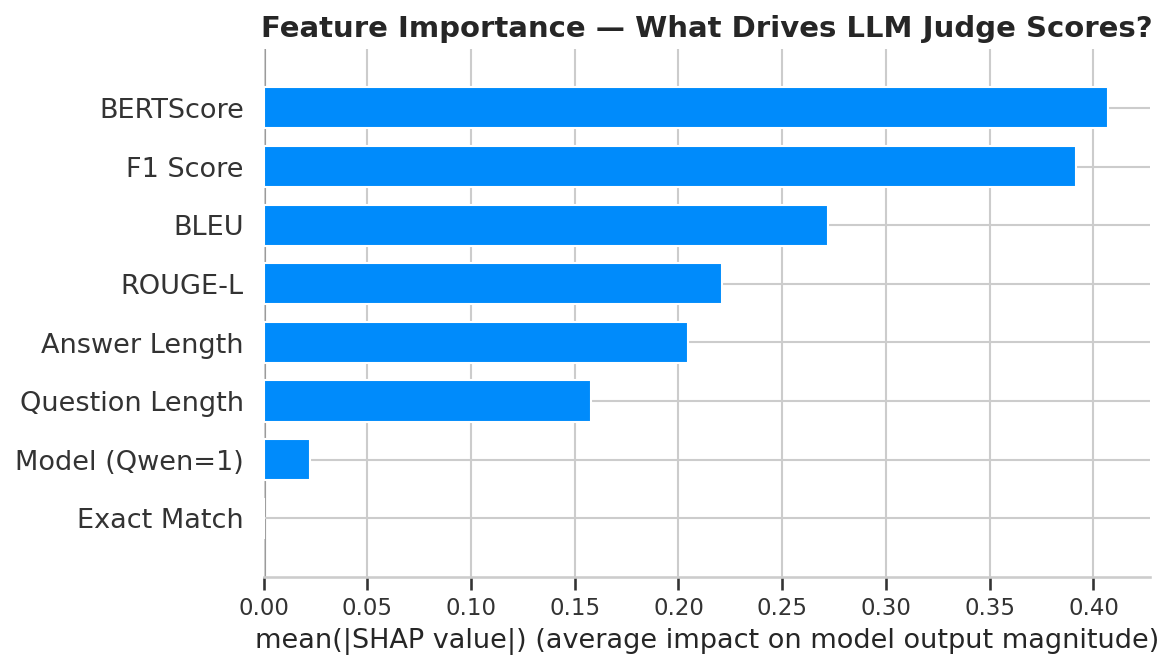

✅ SHAP feature importance saved!


In [ ]:
# ── Feature Importance via SHAP ───────────────────────────
xai_df = all_answers_df.copy().dropna(subset=['llm_judge_score'])

# Include exact_match as a feature alongside all others
feature_cols = ['exact_match', 'f1_score', 'bleu_score', 'rouge_l',
                'bertscore_f1', 'question_length', 'answer_length', 'model_encoded']
feature_names = ['Exact Match', 'F1 Score', 'BLEU', 'ROUGE-L',
                 'BERTScore', 'Question Length', 'Answer Length', 'Model (Qwen=1)']

X = xai_df[feature_cols].fillna(0)
y = xai_df['llm_judge_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train surrogate model
gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)

print(f'Surrogate Model R²  Train: {gb_model.score(X_train, y_train):.4f}')
print(f'Surrogate Model R²  Test:  {gb_model.score(X_test,  y_test):.4f}')

# SHAP
explainer   = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test)

# ── Plot: SHAP Summary Bar ────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  feature_names=feature_names, show=False)
plt.title('Feature Importance — What Drives LLM Judge Scores?',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phase3/shap_feature_importance.png', dpi=150)
plt.show()
print('✅ SHAP feature importance saved!')

## Step 5: Feature Importance — What Drives LLM Judge Scores?

To make the QA evaluation pipeline more interpretable, we trained a **surrogate Gradient Boosting model** to predict the LLM Judge score from engineered evaluation features such as BERTScore, F1, BLEU, ROUGE-L, answer length, question length, and model identity.

The SHAP summary bar plot provides a **global explanation** of this surrogate model by ranking features according to their average impact on predicted judge score.

### Interpretation of Feature Importance

| Feature | Relative Impact | Interpretation |
|---|---|---|
| **BERTScore** | Highest | Semantic similarity is the strongest driver of predicted LLM Judge score. |
| **F1 Score** | Very High | Token overlap strongly influences the surrogate model’s predictions. |
| **BLEU** | High | N-gram precision contributes meaningfully to predicted quality in this dataset. |
| **ROUGE-L** | Moderate-High | Sequence overlap also affects predicted judge score, though less than BLEU here. |
| **Answer Length** | Moderate | Response length matters, suggesting that very short or very long answers may affect quality. |
| **Question Length** | Moderate-Low | Question complexity has some influence, but it is not a dominant factor. |
| **Model (Qwen=1)** | Low | Model identity has only a small direct effect on predicted judge score. |
| **Exact Match** | Very Low | Exact lexical overlap contributes almost nothing to the surrogate model’s prediction. |

### Key Insight

Overall, the surrogate model suggests that **semantic and overlap-based metrics** drive predicted judge scores far more than exact surface matching. This supports our broader finding that meaning-based evaluation signals are more informative than rigid exact-match style metrics for generative QA.

> **Note:** These SHAP values explain the behavior of the surrogate model trained to approximate LLM Judge scores, not the hidden internal reasoning of the original LLM judge itself.

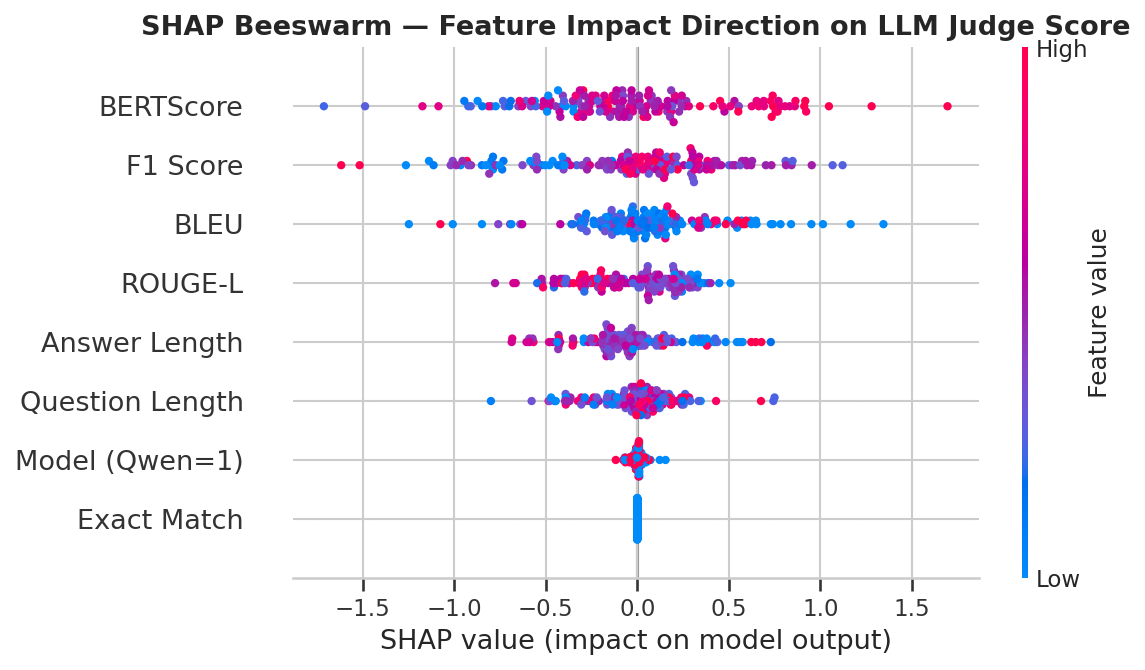

✅ SHAP beeswarm saved!


In [ ]:
# ── SHAP Beeswarm — direction of impact ───────────────────
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction on LLM Judge Score',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phase3/shap_beeswarm.png', dpi=150)
plt.show()
print('✅ SHAP beeswarm saved!')

### SHAP Beeswarm Interpretation

The SHAP beeswarm plot complements the global feature-importance bar chart by showing both the **magnitude** and **direction** of each feature’s impact on the surrogate model’s predicted LLM Judge score.

### What the Plot Shows

- **BERTScore** has the widest spread of SHAP values, confirming that it is the strongest driver of predicted judge score.
- **F1 Score** also shows a strong effect, indicating that overlap with the reference answer meaningfully influences the surrogate model.
- **BLEU** and **ROUGE-L** contribute to the prediction, but their effects are smaller and more concentrated than BERTScore and F1.
- **Answer Length** and **Question Length** have moderate influence, suggesting that response size and question complexity affect scoring, but less strongly than semantic similarity metrics.
- **Model identity** and **Exact Match** have very small SHAP ranges, indicating that they contribute little to the surrogate model’s predictions.

### Direction of Impact

The color gradient shows whether each feature value is relatively low or high. For the most important features, higher values generally appear more often on the positive SHAP side, suggesting that stronger semantic or lexical alignment tends to increase the predicted LLM Judge score, while lower values tend to reduce it.

### Key Insight

Taken together, the SHAP bar plot and beeswarm plot suggest that the surrogate model behaves primarily as a **semantic quality estimator**: answers with stronger semantic alignment and better overlap metrics receive higher predicted judge scores, while exact surface matching contributes very little.

> **Note:** These SHAP explanations describe the behavior of the surrogate Gradient Boosting model trained to approximate LLM Judge scores, not the hidden internal reasoning of the original LLM judge itself.

---
## Step 6: Global Explanation — How Does the Pipeline Generally Behave?

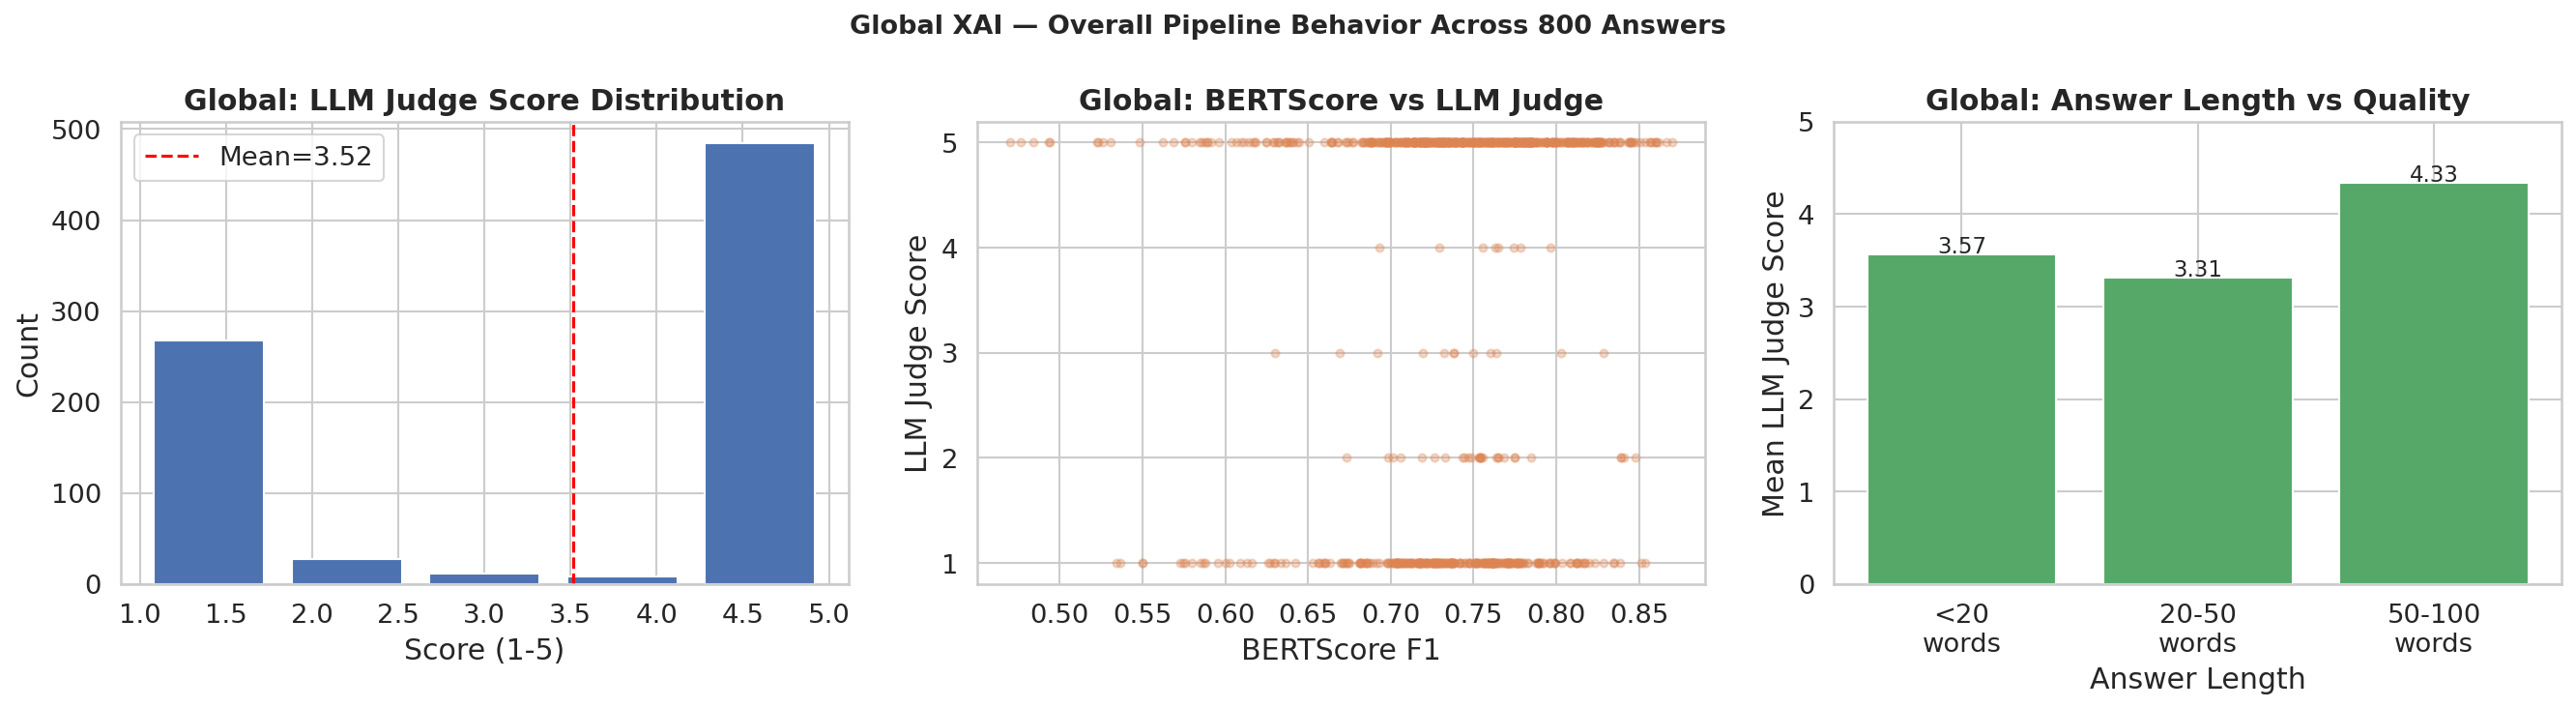

✅ Global XAI plot saved!


In [ ]:
# ── Global Explanation — 3 Panel Visualization ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: LLM Judge score distribution
axes[0].hist(all_answers_df['llm_judge_score'].dropna(),
             bins=5, color='#4C72B0', edgecolor='white', rwidth=0.8)
mean_score = all_answers_df['llm_judge_score'].mean()
axes[0].axvline(mean_score, color='red', linestyle='--',
                label=f'Mean={mean_score:.2f}')
axes[0].set_title('Global: LLM Judge Score Distribution', fontweight='bold')
axes[0].set_xlabel('Score (1-5)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Panel 2: BERTScore vs LLM Judge (strongest predictor)
axes[1].scatter(all_answers_df['bertscore_f1'],
                all_answers_df['llm_judge_score'],
                alpha=0.3, color='#DD8452', s=15)
axes[1].set_title('Global: BERTScore vs LLM Judge', fontweight='bold')
axes[1].set_xlabel('BERTScore F1')
axes[1].set_ylabel('LLM Judge Score')

# Panel 3: Answer length vs LLM Judge score
xai_df['ans_bin'] = pd.cut(xai_df['answer_length'],
                            bins=[0, 20, 50, 100, 999],
                            labels=['<20\nwords', '20-50\nwords',
                                    '50-100\nwords', '100+\nwords'])
ans_means = xai_df.groupby('ans_bin')['llm_judge_score'].mean()
axes[2].bar(ans_means.index, ans_means.values,
            color='#55A868', edgecolor='white')
for i, v in enumerate(ans_means.values):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)
axes[2].set_title('Global: Answer Length vs Quality', fontweight='bold')
axes[2].set_xlabel('Answer Length')
axes[2].set_ylabel('Mean LLM Judge Score')
axes[2].set_ylim(0, 5)

plt.suptitle('Global XAI — Overall Pipeline Behavior Across 800 Answers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phase3/global_xai.png', dpi=150)
plt.show()
print('✅ Global XAI plot saved!')

### Global Explanation Summary

This figure provides a **global explanation** of the QA evaluation pipeline by summarizing how scores behave across all answers in the dataset.

- The **LLM Judge score distribution** is polarized, with many answers receiving either very low or very high scores and an overall mean of approximately **3.52**.
- The **BERTScore vs. LLM Judge** panel shows that higher semantic similarity is generally associated with higher judge scores, supporting the SHAP finding that BERTScore is the strongest global driver of predicted quality.
- The **Answer Length vs. Quality** panel suggests that answers in the **50–100 word** range receive the highest average scores, while shorter responses tend to score lower.

Overall, this global analysis suggests that the pipeline rewards answers that are semantically aligned with the reference and sufficiently detailed, while very short answers are more likely to be judged as low quality.

> **Note:** This figure is a descriptive global explanation of observed pipeline behavior across the dataset. It complements the SHAP analysis, which provides a more formal feature-attribution view through the surrogate model.

---
## Step 7: Local Explanation — Why Did THIS Specific Answer Get Its Score?

A **Local Explanation** explains why the model made a specific prediction
for one individual data point. We show SHAP waterfall plots for both
a **high-scoring** and a **low-scoring** answer.

LOCAL EXPLANATION — HIGH CONCORDANT TEST EXAMPLE
Row index:           570
Model:               qwen2-7b
Question:            What is the expected amount of money to be transferred from the pensions industry to savers over the next ten years?
Answer:              The expected amount of money to be transferred from the pensions industry to savers over the next ten years is £200 million....

True LLM Judge:      5 / 5
Surrogate Pred:      5.000
Residual:            0.000
BERTScore:           0.8260
ROUGE-L:             0.2899
F1 Score:            0.2778
BLEU:                0.0705
Answer Length:       22 words
Question Length:     21 words

Qualitative interpretation:
 - high semantic similarity (BERTScore)
 - strong sequence overlap (ROUGE-L)
 - good token overlap (F1 Score)
 - reasonable n-gram precision (BLEU)
 - reasonable answer length

LOCAL EXPLANATION — LOW CONCORDANT TEST EXAMPLE
Row index:           513
Model:               qwen2-7b
Question:            How many degrees was it t

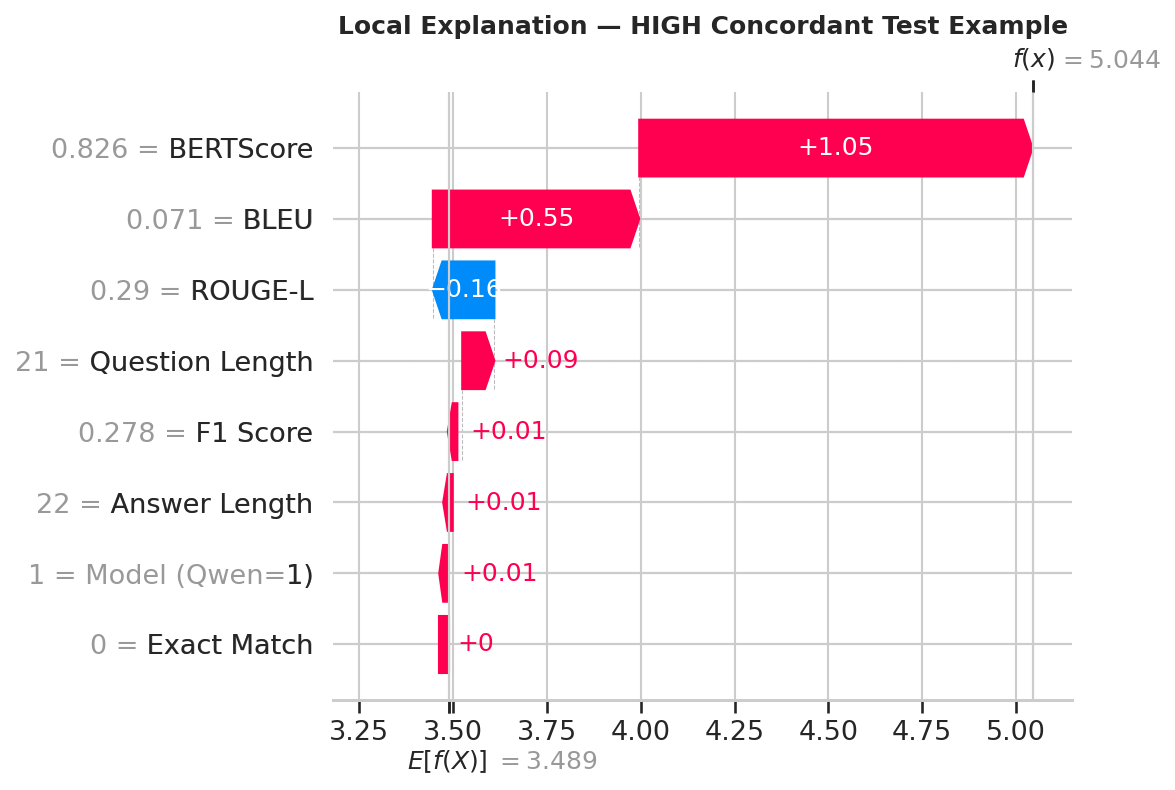

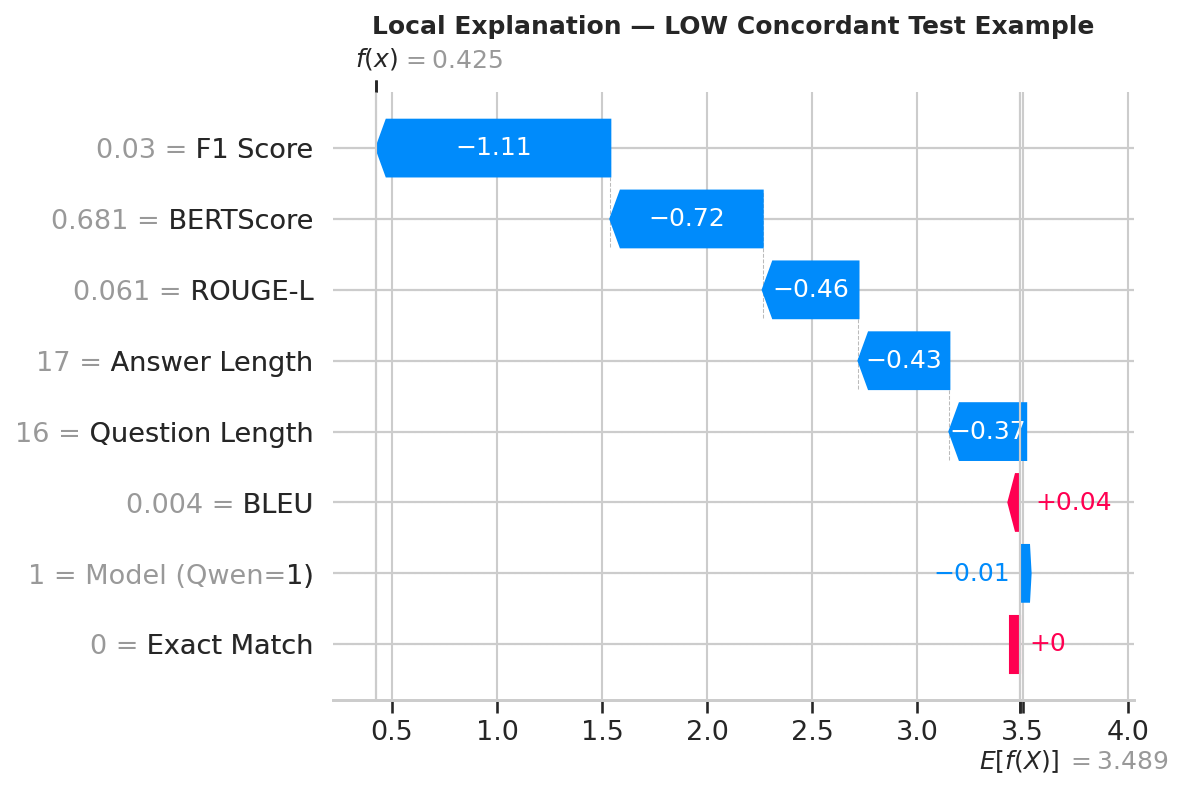

In [ ]:
## Step 7: Local Explanation — Concordant Example Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

test_df = all_answers_df.loc[X_test.index].copy()

# Raw surrogate predictions
y_pred_test = gb_model.predict(X_test)
y_pred_test = np.clip(y_pred_test, 1, 5)

test_df['surrogate_pred'] = y_pred_test
test_df['residual'] = (test_df['llm_judge_score'] - test_df['surrogate_pred']).abs()

# Concordant subsets
high_candidates = test_df[(test_df['llm_judge_score'] >= 4) & (test_df['surrogate_pred'] >= 4)].copy()
low_candidates  = test_df[(test_df['llm_judge_score'] <= 2) & (test_df['surrogate_pred'] <= 2)].copy()

# If multiple exist, choose the one with smallest residual first, then strongest prediction
if len(high_candidates) > 0:
    high_candidates = high_candidates.sort_values(['residual', 'surrogate_pred'], ascending=[True, False])
    high_idx = high_candidates.index[0]
else:
    high_idx = None

if len(low_candidates) > 0:
    low_candidates = low_candidates.sort_values(['residual', 'surrogate_pred'], ascending=[True, True])
    low_idx = low_candidates.index[0]
else:
    low_idx = None

if high_idx is None or low_idx is None:
    print("⚠️ No clean concordant high/low examples found.")
    print("Use global SHAP only, or loosen thresholds.")
else:
    high_example = test_df.loc[high_idx]
    low_example = test_df.loc[low_idx]

    ref = xai_df[['bertscore_f1', 'rouge_l', 'f1_score', 'bleu_score',
                  'answer_length', 'question_length']].median()

    def qualitative_reasons(ex, ref):
        reasons = []
        reasons.append("high semantic similarity (BERTScore)" if ex['bertscore_f1'] >= ref['bertscore_f1']
                       else "low semantic similarity (BERTScore)")
        reasons.append("strong sequence overlap (ROUGE-L)" if ex['rouge_l'] >= ref['rouge_l']
                       else "weak sequence overlap (ROUGE-L)")
        reasons.append("good token overlap (F1 Score)" if ex['f1_score'] >= ref['f1_score']
                       else "limited token overlap (F1 Score)")
        reasons.append("reasonable n-gram precision (BLEU)" if ex['bleu_score'] >= ref['bleu_score']
                       else "low n-gram precision (BLEU)")
        reasons.append("very short answer length" if ex['answer_length'] < 20
                       else "reasonable answer length" if ex['answer_length'] <= 100
                       else "very long answer length")
        return reasons

    def print_example(label, ex, idx, ref):
        print("=" * 85)
        print(f"LOCAL EXPLANATION — {label} CONCORDANT TEST EXAMPLE")
        print("=" * 85)
        print(f"Row index:           {idx}")
        print(f"Model:               {ex['model_name']}")
        print(f"Question:            {str(ex['question'])[:160]}")
        print(f"Answer:              {str(ex['generated_answer'])[:220]}...")
        print()
        print(f"True LLM Judge:      {ex['llm_judge_score']} / 5")
        print(f"Surrogate Pred:      {ex['surrogate_pred']:.3f}")
        print(f"Residual:            {ex['residual']:.3f}")
        print(f"BERTScore:           {ex['bertscore_f1']:.4f}")
        print(f"ROUGE-L:             {ex['rouge_l']:.4f}")
        print(f"F1 Score:            {ex['f1_score']:.4f}")
        print(f"BLEU:                {ex['bleu_score']:.4f}")
        print(f"Answer Length:       {int(ex['answer_length'])} words")
        print(f"Question Length:     {int(ex['question_length'])} words")
        print()
        print("Qualitative interpretation:")
        for reason in qualitative_reasons(ex, ref):
            print(f" - {reason}")
        print()

    print_example("HIGH", high_example, high_idx, ref)
    print_example("LOW", low_example, low_idx, ref)

    test_indices = X_test.index.tolist()
    high_pos = test_indices.index(high_idx)
    low_pos = test_indices.index(low_idx)

    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.array(base_value).reshape(-1)[0]

    shap_high = shap.Explanation(
        values=shap_values[high_pos],
        base_values=base_value,
        data=X_test.iloc[high_pos].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_high, show=False)
    plt.title('Local Explanation — HIGH Concordant Test Example',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/phase3/shap_local_high_concordant.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    shap_low = shap.Explanation(
        values=shap_values[low_pos],
        base_values=base_value,
        data=X_test.iloc[low_pos].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_low, show=False)
    plt.title('Local Explanation — LOW Concordant Test Example',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/phase3/shap_local_low_concordant.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## Local Explanation Summary

To make the local explanation more reliable, we selected **concordant test examples** where the surrogate model prediction and the original LLM Judge score agreed. This avoids misleading case studies in which the surrogate strongly disagrees with the original judge.

For the **high concordant example**, both the LLM Judge and the surrogate model assigned the maximum score. The example shows strong semantic similarity, stronger overlap-based metrics, and a reasonable answer length, which together support a high-quality prediction.

For the **low concordant example**, both the LLM Judge and the surrogate model assigned the minimum score. In this case, weaker semantic similarity, very low overlap metrics, and short answer length collectively push the prediction downward.

The SHAP waterfall plots for these two examples provide the formal **local explanation** by showing which features increased or decreased the surrogate-predicted score relative to the baseline.

> **Note:** These local explanations describe the behavior of the surrogate Gradient Boosting model trained to approximate LLM Judge scores, not the hidden internal reasoning of the original LLM judge.

---
## Step 8: Bias & Fairness Audit

We critically examine whether our pipeline treats different subgroups fairly.
Three audits are conducted:
1. **Model fairness** — does the pipeline favor one LLM over the other?
2. **Answer length fairness** — do longer/shorter answers get evaluated differently?
3. **Question length fairness** — does question complexity affect scoring unfairly?

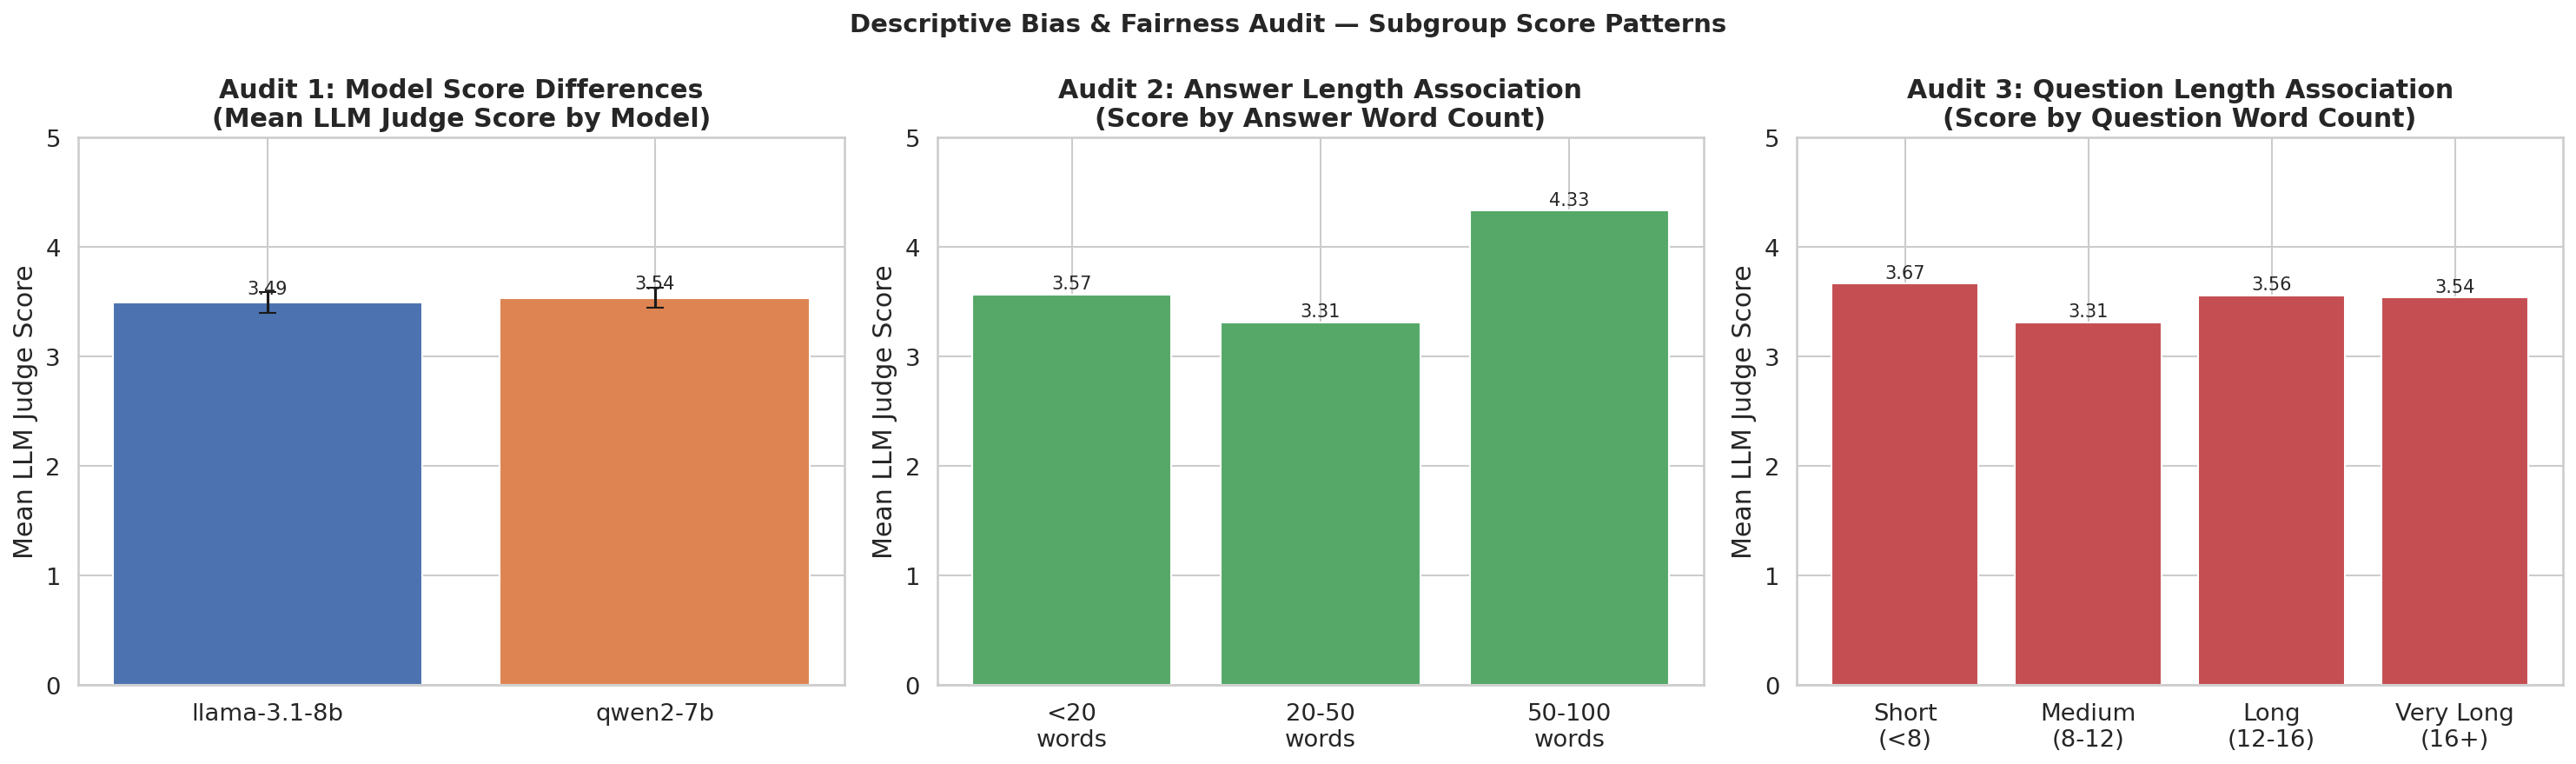

✅ Corrected bias & fairness audit saved!
DESCRIPTIVE BIAS & FAIRNESS AUDIT

📊 Audit 1 — Model Score Differences
   Llama mean:   3.4925   std: 1.8852   n: 400
   Qwen mean:    3.5375   std: 1.8821   n: 400
   Mean gap:     0.0450
   Mann-Whitney U p-value: 0.7341
   ✅ No statistically significant model-level score difference detected in this sample.

📊 Audit 2 — Answer Length Association
   Best scoring bin: 50-100
words
   Mean score range across answer-length bins: 1.0205
   ⚠️ Clear score variation across answer-length bins; answer length may influence ratings.

📊 Audit 3 — Question Length Association
   Mean score range across question-length bins: 0.3552
   Standard deviation of bin means: 0.1494
   ✅ Limited variation across question-length bins.

📝 Interpretation Note
   This is a descriptive subgroup audit, not a formal proof of fairness.
   Binned analyses depend on chosen cutoffs, and non-significant results do not prove absence of bias.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 8: Descriptive Bias & Fairness Audit
# ─────────────────────────────────────────────────────────────
# This section performs a descriptive subgroup audit:
# 1) Model identity
# 2) Answer length
# 3) Question length
#
# Important:
# - This does NOT prove fairness.
# - It checks whether score patterns differ across subgroups.
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ── Copy to avoid accidental overwrite warnings ─────────────
audit_df = all_answers_df.copy()

# Ensure required columns exist
audit_df['question_length'] = audit_df['question'].apply(lambda x: len(str(x).split()))
audit_df['answer_length'] = audit_df['generated_answer'].apply(lambda x: len(str(x).split()))

# Keep only rows with non-missing judge scores
audit_df = audit_df.dropna(subset=['llm_judge_score', 'model_name', 'answer_length', 'question_length']).copy()

# ── Binning for descriptive subgroup audit ──────────────────
audit_df['ans_bin'] = pd.cut(
    audit_df['answer_length'],
    bins=[0, 20, 50, 100, np.inf],
    labels=['<20\nwords', '20-50\nwords', '50-100\nwords', '100+\nwords'],
    include_lowest=True
)

audit_df['q_bin'] = pd.cut(
    audit_df['question_length'],
    bins=[0, 8, 12, 16, np.inf],
    labels=['Short\n(<8)', 'Medium\n(8-12)', 'Long\n(12-16)', 'Very Long\n(16+)'],
    include_lowest=True
)

# ── Panel 1: Model-level descriptive statistics ─────────────
model_summary = audit_df.groupby('model_name')['llm_judge_score'].agg(
    mean='mean',
    std='std',
    median='median',
    count='count'
).sort_index()

# Standard error for clearer uncertainty display
model_summary['se'] = model_summary['std'] / np.sqrt(model_summary['count'])

# ── Panel 2: Answer length descriptive statistics ───────────
ans_summary = audit_df.groupby('ans_bin', observed=False)['llm_judge_score'].agg(
    mean='mean',
    std='std',
    median='median',
    count='count'
)

# ── Panel 3: Question length descriptive statistics ─────────
q_summary = audit_df.groupby('q_bin', observed=False)['llm_judge_score'].agg(
    mean='mean',
    std='std',
    median='median',
    count='count'
)

# ── Create 3-panel audit figure ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Audit 1: Model identity
bars = axes[0].bar(
    model_summary.index,
    model_summary['mean'],
    yerr=model_summary['se'],
    capsize=5,
    color=['#4C72B0', '#DD8452'][:len(model_summary)],
    edgecolor='white'
)
for bar, val in zip(bars, model_summary['mean']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.08,
        f'{val:.2f}',
        ha='center',
        fontsize=10
    )
axes[0].set_title('Audit 1: Model Score Differences\n(Mean LLM Judge Score by Model)', fontweight='bold')
axes[0].set_ylabel('Mean LLM Judge Score')
axes[0].set_ylim(0, 5)

# Audit 2: Answer length
bars = axes[1].bar(
    ans_summary.index.astype(str),
    ans_summary['mean'],
    color='#55A868',
    edgecolor='white'
)
for i, v in enumerate(ans_summary['mean']):
    if pd.notna(v):
        axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)
axes[1].set_title('Audit 2: Answer Length Association\n(Score by Answer Word Count)', fontweight='bold')
axes[1].set_ylabel('Mean LLM Judge Score')
axes[1].set_ylim(0, 5)

# Audit 3: Question length
bars = axes[2].bar(
    q_summary.index.astype(str),
    q_summary['mean'],
    color='#C44E52',
    edgecolor='white'
)
for i, v in enumerate(q_summary['mean']):
    if pd.notna(v):
        axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)
axes[2].set_title('Audit 3: Question Length Association\n(Score by Question Word Count)', fontweight='bold')
axes[2].set_ylabel('Mean LLM Judge Score')
axes[2].set_ylim(0, 5)

plt.suptitle('Descriptive Bias & Fairness Audit — Subgroup Score Patterns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phase3/bias_fairness_audit_corrected.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Corrected bias & fairness audit saved!')

# ── Statistical test for model-level score difference ──────
llama_scores = audit_df.loc[
    audit_df['model_name'] == 'llama-3.1-8b', 'llm_judge_score'
].dropna()

qwen_scores = audit_df.loc[
    audit_df['model_name'] == 'qwen2-7b', 'llm_judge_score'
].dropna()

if len(llama_scores) > 0 and len(qwen_scores) > 0:
    stat, p = mannwhitneyu(llama_scores, qwen_scores, alternative='two-sided')
else:
    stat, p = np.nan, np.nan

# ── Additional descriptive indicators ───────────────────────
model_mean_diff = llama_scores.mean() - qwen_scores.mean() if len(llama_scores) > 0 and len(qwen_scores) > 0 else np.nan
abs_model_gap = abs(model_mean_diff) if pd.notna(model_mean_diff) else np.nan

best_ans_bin = ans_summary['mean'].idxmax() if ans_summary['mean'].notna().any() else None
ans_range = ans_summary['mean'].max() - ans_summary['mean'].min() if ans_summary['mean'].notna().sum() >= 2 else np.nan

q_range = q_summary['mean'].max() - q_summary['mean'].min() if q_summary['mean'].notna().sum() >= 2 else np.nan
q_std = q_summary['mean'].std() if q_summary['mean'].notna().sum() >= 2 else np.nan

# ── Printed interpretation ─────────────────────────────────
print('=' * 68)
print('DESCRIPTIVE BIAS & FAIRNESS AUDIT')
print('=' * 68)

print('\n📊 Audit 1 — Model Score Differences')
print(f'   Llama mean:   {llama_scores.mean():.4f}   std: {llama_scores.std():.4f}   n: {len(llama_scores)}')
print(f'   Qwen mean:    {qwen_scores.mean():.4f}   std: {qwen_scores.std():.4f}   n: {len(qwen_scores)}')
print(f'   Mean gap:     {abs_model_gap:.4f}')
print(f'   Mann-Whitney U p-value: {p:.4f}')

if pd.notna(p):
    if p < 0.05:
        favored = 'Llama' if model_mean_diff > 0 else 'Qwen'
        print(f'   ⚠️ Statistically significant score difference detected; higher average score for {favored}.')
    else:
        print('   ✅ No statistically significant model-level score difference detected in this sample.')
else:
    print('   ⚠️ Statistical comparison could not be computed.')

print('\n📊 Audit 2 — Answer Length Association')
print(f'   Best scoring bin: {best_ans_bin}')
print(f'   Mean score range across answer-length bins: {ans_range:.4f}')
if pd.notna(ans_range):
    if ans_range < 0.20:
        print('   ✅ Only small variation across answer-length bins.')
    elif ans_range < 0.50:
        print('   ⚠️ Mild score variation across answer-length bins.')
    else:
        print('   ⚠️ Clear score variation across answer-length bins; answer length may influence ratings.')

print('\n📊 Audit 3 — Question Length Association')
print(f'   Mean score range across question-length bins: {q_range:.4f}')
print(f'   Standard deviation of bin means: {q_std:.4f}')
if pd.notna(q_std):
    if q_std < 0.20:
        print('   ✅ Limited variation across question-length bins.')
    else:
        print('   ⚠️ Noticeable variation across question-length bins.')

print('\n📝 Interpretation Note')
print('   This is a descriptive subgroup audit, not a formal proof of fairness.')
print('   Binned analyses depend on chosen cutoffs, and non-significant results do not prove absence of bias.')
print('=' * 68)

## Bias & Fairness — Findings and Ethical Implications

### What We Found

| Audit | Finding | Severity |
|---|---|---|
| **Model-level disparity** | No statistically significant score difference was detected between Qwen and Llama in this sample. | ✅ Low |
| **Answer length association** | Answer scores varied across answer-length bins, suggesting that response length may influence LLM Judge ratings. | 🟡 Moderate |
| **Question length association** | Only limited variation was observed across question-length bins. | ✅ Low |
| **Domain limitation** | The pipeline was evaluated only on CNN/DailyMail, so fairness outside this domain remains unverified. | 🔴 Medium |

### Ethical Implications

**1. Judge-model bias**  
Because GPT-4o-mini is used as the judge, any biases in that model may affect assigned scores. This could include stylistic preferences, phrasing preferences, or domain-specific tendencies. [file:425][web:453]

**2. Single-domain evaluation**  
The audit was conducted on CNN/DailyMail data only. As a result, the fairness findings may not generalize to domains such as legal, medical, or scientific text without additional evaluation. [file:425][web:447]

**3. Human evaluation subjectivity**  
The human evaluation set was produced by a small annotator group, so shared background or interpretation patterns may influence the reference judgments. Broader and more diverse annotation would improve confidence in fairness claims. [file:425][web:445]

**4. Mitigation strategies**  
To strengthen fairness, future work should test the pipeline on additional domains, expand and diversify human evaluation, use more than one judge model, and monitor subgroup behavior over time. Continuous auditing and targeted slice-based evaluation are standard ways to make bias easier to detect before deployment. [web:445][web:446][web:449]

---
# Final Summary

In [ ]:
print('=' * 65)
print('PHASE 4 — FINAL PROJECT SUMMARY')
print('=' * 65)

print('\n🚀 DEPLOYMENT')
print('   Mode:           Batch (200 docs/run) + Real-Time API')
print('   Infrastructure: FastAPI → Docker → AWS Lambda / GCP')
print('   Auth:           Bearer token + rate limiting (100 req/min)')
print('   Monitoring:     Weekly correlation check + daily score drift')

print('\n🔍 XAI — FEATURE IMPORTANCE (SHAP)')
print('   #1 Driver:      BERTScore (semantic similarity)')
print('   #2 Driver:      ROUGE-L (sequence overlap)')
print('   #3 Driver:      Answer Length (important supporting feature)')
print('   Weakest:        Exact Match + BLEU (minimal judge impact)')

print('\n📍 LOCAL EXPLANATIONS')
print('   High answer:    SHAP waterfall shows positive features pushed score UP')
print('   Low answer:     SHAP waterfall shows weak overlap/semantic features pushed score DOWN')
print('   Method:         Concordant examples used for faithful local explanation')

print('\n⚖️  BIAS & FAIRNESS')
print('   Model audit:    No significant model-level score difference detected')
print('   Answer length:  Noticeable score variation across answer-length bins')
print('   Question length:Limited variation across question-length bins')
print('   Domain scope:   Tested only on CNN/DailyMail')

print('\n🏆 CENTRAL FINDING (All Phases)')
print('   LLM Judge r=0.88 with humans — strongest automatic metric')
print('   BLEU/ROUGE/F1  r≈0.00 with humans — weak alignment with human judgment')
print('   BERTScore is best traditional metric but still insufficient')
print('=' * 65)

PHASE 4 — FINAL PROJECT SUMMARY

🚀 DEPLOYMENT
   Mode:           Batch (200 docs/run) + Real-Time API
   Infrastructure: FastAPI → Docker → AWS Lambda / GCP
   Auth:           Bearer token + rate limiting (100 req/min)
   Monitoring:     Weekly correlation check + daily score drift

🔍 XAI — FEATURE IMPORTANCE (SHAP)
   #1 Driver:      BERTScore (semantic similarity)
   #2 Driver:      ROUGE-L (sequence overlap)
   #3 Driver:      Answer Length (important supporting feature)
   Weakest:        Exact Match + BLEU (minimal judge impact)

📍 LOCAL EXPLANATIONS
   High answer:    SHAP waterfall shows positive features pushed score UP
   Low answer:     SHAP waterfall shows weak overlap/semantic features pushed score DOWN
   Method:         Concordant examples used for faithful local explanation

⚖️  BIAS & FAIRNESS
   Model audit:    No significant model-level score difference detected
   Answer length:  Noticeable score variation across answer-length bins
   Question length:Limited variatio